In [8]:
import pandas as pd
import numpy as np
import glob, os, vcf, itertools, subprocess, shutil

import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez, Seq, SeqIO

cc_df = pd.read_csv("~/who-analysis/data/drug_CC.csv")
cc_df_internal = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/critical_concentrations.csv", index_col=[0])

h37Rv_genes_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# dataframe of the gene(s) that each position of H37Rv is in. If not a gene, then the region is NC_{num}. This was made from the dataframe above, so the same genes and noncoding regions are reflected
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

drug_abbr_dict = {'Amikacin': 'AMI',
                  'Bedaquiline': 'BDQ',
                  'Capreomycin': 'CAP',
                  'Clofazimine': 'CFZ',
                  'Delamanid': 'DLM',
                  'Ethambutol': 'EMB',
                  'Ethionamide': 'ETH',
                  'Isoniazid': 'INH',
                  'Kanamycin': 'KAN',
                  'Levofloxacin': 'LFX',
                  'Linezolid': 'LZD',
                  'Moxifloxacin': 'MXF',
                  'Ofloxacin': 'OFX',
                  'Prothionamide': 'PRO',
                  'Pyrazinamide': 'PZA',
                  'Rifampicin': 'RIF',
                  'Rifabutin': 'RFB',
                  'Streptomycin': 'STM'
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

who_variants_V1 = pd.read_excel("/home/sak0914/who-analysis/results/WHO-catalog-V1.xlsx", sheet_name='Mutation_catalogue')
who_variants = pd.read_csv("/home/sak0914/who-analysis/results/WHO-catalog-V2.csv", header=[2])

MIC_ML_og = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv")
cryptic_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
df_rollingDB = pd.read_csv("../MIC_data/rollingDB_MIC_raw.csv")

/tmp/ipykernel_8477/2569935168.py:43: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("/home/sak0914/who-analysis/results/WHO-catalog-V2.csv", header=[2])


In [83]:
need_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/anna/sai/master_table_resistance_updated_paths.csv")
print(len(need_paths))

del need_paths['Unnamed: 0']
del need_paths['index']

search_lst = need_paths.loc[pd.isnull(need_paths['updated_path'])][['Isolate', 'run', 'biosample', 'Isolate_original', 'accessions']]

23051


/tmp/ipykernel_8477/1605945847.py:1: DtypeWarning: Columns (5,8,9,13,18,21) have mixed types. Specify dtype option on import or set low_memory=False.
  need_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/anna/sai/master_table_resistance_updated_paths.csv")


In [86]:
need_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/anna/sai/master_table_resistance_updated_paths.csv")
print(len(need_paths))

del need_paths['Unnamed: 0']
del need_paths['index']

search_lst = need_paths.loc[pd.isnull(need_paths['updated_path'])].dropna(subset='biosample').biosample.values

23051


/tmp/ipykernel_8477/3872663861.py:1: DtypeWarning: Columns (5,8,9,13,18,21) have mixed types. Specify dtype option on import or set low_memory=False.
  need_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/anna/sai/master_table_resistance_updated_paths.csv")


In [ ]:
pd.Series(np.unique(need_paths['accessions'])).to_csv("../../data_cleaning/Anna_search_accessions.csv", index=False)

In [88]:
search_lst

array(['ERS2401081', 'SAMN03653253', 'SAMN03653251', ..., 'SAMEA1397353',
       'SAMEA1397350', 'SAMEA1397399'], dtype=object)

In [ ]:
# d["updated_path"] = ""
# n_updated = 0

# for idx, row in d.iterrows():
    
#     if os.path.isfile(row.path):
#         d.loc[idx, "updated_path"] = row.path
        
#     else:
#         new_path = row.path
#         new_path = new_path.replace(row.Isolate, row.accessions)
#         new_path = new_path.replace(".vcf", "_variants.vcf")
        
#         if os.path.isfile(new_path):
#             d.loc[idx, "updated_path"] = row.path
#             n_updated += 1
            
# #         else:

In [89]:
search_lst = need_paths.loc[pd.isnull(need_paths['updated_path'])][['Isolate', 'run', 'biosample', 'Isolate_original', 'accessions']]

In [138]:
need_paths.query("~(Isolate.str.startswith('ER') | Isolate.str.startswith('SR') | Isolate.str.startswith('SAM'))").query("~Isolate.str.startswith('TDR') & ~Isolate.str.startswith('Peru')")

,Isolate,AMIKACIN,AMOXICILLIN,AMOXICILLIN_CLAVULANATE,CAPREOMYCIN,CIPROFLOXACIN,CLARITHROMYCIN,CLOFAZIMINE,CYCLOSERINE,ETHAMBUTOL,...,PARA_AMINOSALICYLIC_ACID,run,run_combined,bioproject,biosample,internal,path,Isolate_original,accessions,updated_path
3316,NLA009700174,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009700174,ERS2401139,NaN
3317,NLA009601810,R,NaN,NaN,NaN,NaN,NaN,R,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009601810,ERS2401349,NaN
3318,NLA009601659,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009601659,ERS2401184,NaN
3319,NLA009601360,R,NaN,NaN,NaN,NaN,NaN,R,NaN,R,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009601360,ERS2401110,NaN
3320,NLA009600875,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009600875,ERS2401234,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6685,IDR1600058226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,IDR1600058226,SAMN20693569,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...
6686,IDR1600058228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,IDR1600058228,SAMN20693570,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...
6687,IDR1600058231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,IDR1600058231,SAMN26754296,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...
6688,IDR1600058695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,IDR1600058695,SAMN20693571,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...


In [152]:
count = 0

for name in need_paths.query("category=='set4_matthias_new_vcf'").biosample.values:
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_variants.vcf"):
        count += 1

count, len(need_paths.query("category=='set4_matthias_new_vcf'"))

(48, 5313)

In [154]:
need_paths.query("category=='set4_matthias_new_vcf'").dropna(subset='internal')

,Isolate,AMIKACIN,AMOXICILLIN,AMOXICILLIN_CLAVULANATE,CAPREOMYCIN,CIPROFLOXACIN,CLARITHROMYCIN,CLOFAZIMINE,CYCLOSERINE,ETHAMBUTOL,...,PARA_AMINOSALICYLIC_ACID,run,run_combined,bioproject,biosample,internal,path,Isolate_original,accessions,updated_path
0,ERS2401081,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,...,NaN,ERS2401081,ERS2401081,internal,ERS2401081,NLA000301128,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401081,ERS2401081,NaN
12,SRR2024937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,SRR2024937,SRR2024937,PRJNA283583,SAMN03653241,X,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,SRR2024937,SRR2024937,NaN
55,SRR2101732,S,NaN,NaN,S,NaN,NaN,NaN,NaN,R,...,NaN,SRR2101732,SRR2101732,PRJNA282721,SAMN03648979,X,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,SRR2101732,SRR2101732,NaN
56,SRR2101730,S,NaN,NaN,S,NaN,NaN,NaN,NaN,S,...,NaN,SRR2101730,SRR2101730,PRJNA282721,SAMN03648977,X,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,SRR2101730,SRR2101730,NaN
57,SRR2101728,S,NaN,NaN,S,NaN,NaN,NaN,NaN,S,...,NaN,SRR2101728,SRR2101728,PRJNA282721,SAMN03648975,X,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,SRR2101728,SRR2101728,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4548,ERS2401389,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401389,ERS2401389,internal,ERS2401389,NLA000301715,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401389,ERS2401389,NaN
4549,ERS2401378,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401378,ERS2401378,internal,ERS2401378,NLA000301029,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401378,ERS2401378,NaN
4550,ERS2401373,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401373,ERS2401373,internal,ERS2401373,NLA009701444,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401373,ERS2401373,NaN
4551,ERS2401370,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401370,ERS2401370,internal,ERS2401370,NLA009801500,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401370,ERS2401370,NaN


In [139]:
need_paths.loc[pd.isnull(need_paths['accessions'])]

,Isolate,AMIKACIN,AMOXICILLIN,AMOXICILLIN_CLAVULANATE,CAPREOMYCIN,CIPROFLOXACIN,CLARITHROMYCIN,CLOFAZIMINE,CYCLOSERINE,ETHAMBUTOL,...,PARA_AMINOSALICYLIC_ACID,run,run_combined,bioproject,biosample,internal,path,Isolate_original,accessions,updated_path


In [143]:
len(need_paths['accessions']), len(np.unique(need_paths['accessions']))

(23051, 22943)

array(['ERR025833', 'ERR025834', 'ERR025835', ..., 'SRR7131296',
       'SRR7131298', 'SRR7439415'], dtype=object)

In [145]:
need_paths.iloc[need_paths.index.values[need_paths.duplicated('accessions', keep=False)]].sort_values('accessions')

,Isolate,AMIKACIN,AMOXICILLIN,AMOXICILLIN_CLAVULANATE,CAPREOMYCIN,CIPROFLOXACIN,CLARITHROMYCIN,CLOFAZIMINE,CYCLOSERINE,ETHAMBUTOL,...,PARA_AMINOSALICYLIC_ACID,run,run_combined,bioproject,biosample,internal,path,Isolate_original,accessions,updated_path
0,ERS2401081,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,...,NaN,ERS2401081,ERS2401081,internal,ERS2401081,NLA000301128,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401081,ERS2401081,NaN
3391,NLA000301128,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA000301128,ERS2401081,NaN
2244,ERS2401085,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401085,ERS2401085,internal,ERS2401085,NLA009900478,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401085,ERS2401085,NaN
3352,NLA009900478,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,NLA009900478,ERS2401085,NaN
4163,ERS2401088,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,...,NaN,ERS2401088,ERS2401088,internal,ERS2401088,NLA009901354,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS2401088,ERS2401088,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,ERS3089688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ERS3089688,ERS3089688,PRJEB30953,SAMEA5241549,TDR188S166L002,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS3089688,ERS3089688,NaN
2124,TDR190S178L002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,TDR190S178L002,ERS3089691,NaN
899,ERS3089691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ERS3089691,ERS3089691,PRJEB30953,SAMEA5241552,TDR190S178L002,/n/data1/hms/dbmi/farhat/gentb_benchmarking_vc...,ERS3089691,ERS3089691,NaN
2125,TDR192S97L002,NaN,NaN,NaN,R,NaN,NaN,NaN,NaN,R,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,TDR192S97L002,ERS3089693,NaN


In [124]:
count = 0

for i, row in need_paths.iterrows():

    if row['Isolate'].startswith('Peru') and pd.isnull(row['updated_path']):

        new_id = peru_sample_mapping[row['Isolate']]
        
        # if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{new_id}/pilon/{new_id}_variants.vcf"):
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{new_id}/pilon"):
            count += 1
            #need_paths.loc[i, 'updated_path'] = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{new_id}/pilon/{new_id}_variants.vcf"

count

29

In [120]:
new_id

'SAMN05916393'

In [100]:
for i, row in search_lst.query("Isolate.str.startswith('Peru')").iterrows():
    if not os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['accessions']}"):
        print(row['Isolate'])

In [122]:
need_paths.query("Isolate=='Peru5010'")

,Isolate,AMIKACIN,AMOXICILLIN,AMOXICILLIN_CLAVULANATE,CAPREOMYCIN,CIPROFLOXACIN,CLARITHROMYCIN,CLOFAZIMINE,CYCLOSERINE,ETHAMBUTOL,...,PARA_AMINOSALICYLIC_ACID,run,run_combined,bioproject,biosample,internal,path,Isolate_original,accessions,updated_path
5813,Peru5010,R,NaN,NaN,R,NaN,NaN,NaN,NaN,R,...,NaN,NaN,NaN,NaN,NaN,NaN,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,Peru5010,SAMN05916330,NaN


In [106]:
peru_lst = search_lst.query("Isolate.str.startswith('Peru')").Isolate.values
print(len(peru_lst))

29


In [116]:
peru_sample_mapping = dict(zip(isolate_metadata.query("ROLLINGDB_ID.isin(@peru_lst)")['ROLLINGDB_ID'], isolate_metadata.query("ROLLINGDB_ID.isin(@peru_lst)")['BIOSAMPLE_ACCESSION']))
len(peru_sample_mapping)

29

In [121]:
peru_sample_mapping

{'Peru5010': 'SAMN05916330',
 'Peru5019': 'SAMN05916339',
 'Peru5081': 'SAMN05916393',
 'Peru4020': 'SAMN05918536',
 'Peru4561': 'SAMN05918661',
 'Peru4581': 'SAMN05918681',
 'Peru4625': 'SAMN05918724',
 'Peru4629': 'SAMN05918728',
 'Peru4633': 'SAMN05918732',
 'Peru3963': 'SAMN05918918',
 'Peru4124': 'SAMN05919643',
 'Peru2939': 'SAMN06010153',
 'Peru2947': 'SAMN06010161',
 'Peru2975': 'SAMN06010188',
 'Peru3009': 'SAMN06010203',
 'Peru3010': 'SAMN06010204',
 'Peru3025': 'SAMN06010219',
 'Peru3386': 'SAMN06010339',
 'Peru3425': 'SAMN06010340',
 'Peru3422': 'SAMN06010348',
 'Peru3396': 'SAMN06010356',
 'Peru3395': 'SAMN06010357',
 'Peru3341': 'SAMN06010377',
 'Peru3387': 'SAMN06010381',
 'Peru3353': 'SAMN06010401',
 'Peru3390': 'SAMN06010425',
 'Peru3406': 'SAMN06010447',
 'Peru3388': 'SAMN06010450',
 'Peru3379': 'SAMN06010451'}

In [109]:
for i, row in isolate_metadata.query("ROLLINGDB_ID.str.contains('Peru')").iterrows():

    

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
4693,Peru2905,NaN,NaN,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4694,Peru2909,NaN,NaN,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4695,Peru3016,NaN,NaN,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4696,Peru3021,NaN,NaN,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4697,Peru3065,NaN,NaN,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20739,Peru5449,SAMN06094116,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20740,Peru5450,SAMN06094117,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20741,Peru5453,SAMN06094120,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20742,Peru5454,SAMN06094121,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
found_vcfs = []

for i, row in search_lst.iterrows():

    unique_names = np.unique(row.values[~pd.isnull(row.values)])
    
    for id in unique_names:
        if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{id}/pilon/{id}_variants.vcf"):
            found_vcfs.append(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{id}/pilon/{id}_variants.vcf")
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output//pilon/{id}_variants.vcf"):
            found_vcfs.append(f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output//pilon/{id}_variants.vcf")

# len(new_names_mapping), len(search_lst.dropna(subset='biosample').biosample.values)

In [81]:
found_vcfs

['/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600027328/pilon/IDR1600027328_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600018194/pilon/IDR1600018194_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600044262/pilon/IDR1600044262_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1500049548/pilon/IDR1500049548_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1500009344/pilon/IDR1500009344_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1500054145/pilon/IDR1500054145_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1300005060/pilon/IDR1300005060_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1300033719/pilon/IDR1300033719_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1300021110/pilon/IDR1300021110_variants.vcf',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600003443/pilon/IDR1600003443_variants.vcf',
 '/n/data1

In [24]:
new_names_mapping = {}

for name in search_lst.dropna(subset='biosample').biosample.values:
    if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}"):
        new_names_mapping[name] = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}"
    if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/{name}"):
        new_names_mapping[name] = f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/{name}"

len(new_names_mapping), len(search_lst.dropna(subset='biosample').biosample.values)

(4354, 5313)

In [61]:
for name in search_lst.dropna(subset='biosample').biosample.values:
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_variants.vcf"):
        print(name)

SAMEA3402871
SAMEA3402867
SAMEA3402471
SAMEA3402470
SAMEA3401933
SAMEA3401929
SAMEA3401928
SAMEA3402469
SAMEA3401924
SAMEA3403844
SAMEA3403842
SAMEA3403355
SAMEA3403343
SAMEA3402931
SAMEA3402929
SAMEA3402927
SAMEA3402926
SAMEA3402914
SAMEA3403342
SAMEA3401675
SAMEA3400988
SAMEA3400984
SAMEA3393050
SAMEA3392672
SAMEA3392622
SAMEA3403848
SAMEA3403850
SAMEA3403852
SAMEA3420853
SAMEA3414401
SAMEA3414211
SAMEA3414207
SAMEA3414199
SAMEA3404194
SAMEA3404181
SAMEA3404168
SAMEA3404167
SAMEA3404133
SAMEA3404132
SAMEA3404193
SAMEA3414408
SAMEA3420838
SAMEA3416726
SAMEA3416660
SAMEA3414464
SAMEA3414461
SAMEA3414460
SAMEA3414411


In [55]:
search_lst.query("biosample=='SAMEA5241528'")

,Isolate,run,biosample,Isolate_original,accessions
885,ERS3089667,ERS3089667,SAMEA5241528,ERS3089667,ERS3089667


In [58]:
isolate_metadata.query("SAMPLE=='ERS3089667'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
21947,SAMEA5282399,SAMEA5282399,Peru,TDR,1,Mycobacterium tuberculosis,1,ERS3089667,ERR3132149,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:44,2019-05-31 13:41:57,NaN,NaN,TDR_169


In [59]:
#set(search_lst.biosample) - set(search_names)

In [50]:
search_names = [os.path.basename(fName) for fName in glob.glob(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAM*")]
search_names_2 = [os.path.basename(fName) for fName in glob.glob(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/ERS*")]

len(search_names), len(search_names_2)

(49346, 0)

In [40]:
# for name in os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"):
#     if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/prinseq"):
#         if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon"):
#             print(name)

In [33]:
isolate_metadata.query("RUN=='ERR2514914'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample


In [35]:
os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMEA1397399")

True

In [12]:
seqDict = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/seqDict.pkl")

In [14]:
seqDict['pncA'].columns

Index([2289241.0, 2289240.0, 2289239.0, 2289238.0, 2289237.0, 2289236.0,
       2289235.0, 2289234.0, 2289233.0, 2289232.0,
       ...
       2288690.0, 2288689.0, 2288688.0, 2288687.0, 2288686.0, 2288685.0,
       2288684.0, 2288683.0, 2288682.0, 2288681.0],
      dtype='object', length=615)

In [68]:
gene = 'rpsA'
locus = 'rpsA'
start, end = h37Rv_genes_df.query("Symbol==@gene")[['Start', 'End']].values[0]

In [69]:
str_column_names = [col if type(col) == str else str(int(col)) for col in seqDict[locus].columns]
seqDict[locus].columns = str_column_names

In [76]:
if str(end) == seqDict[locus].columns[-1]:
    print('yes')

yes


In [75]:
seqDict[locus].columns[-1]

'1834987'

In [74]:
end

1834987

In [70]:
start, end

(1833542, 1834987)

In [71]:
seqDict[locus]

,1833493,1833494,1833495,1833496,1833497,1833498,1833499,1833500,1833501,1833502,...,1834979,1834980,1834981,1834982,1834983,1834984,1834985,rpsA_0,1834986,1834987
Isolate,,,,,,,,,,,,,,,,,,,,,
SAMEA3392614,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMEA3392622,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMEA3392626,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMEA3392628,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMEA3392629,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMN06094215,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMN06094216,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A
SAMN06094220,G,T,A,C,C,A,A,T,C,T,...,A,G,C,G,C,T,T,-,G,A


In [3]:
group1_WHO_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv", sep='\t')
group1_WHO_variants.ISOLATE.nunique()

13276

In [73]:
group1_WHO_variants.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv", index=False, sep='\t')

In [74]:
pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv", sep='\t')

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE,MUT
0,7362,G,C,PASS,2678.0,1.00,81,33,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,20542,gyrA_p.Glu21Gln
1,7585,G,C,PASS,1986.0,1.00,61,33,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,20542,gyrA_p.Ser95Thr
2,9304,G,A,PASS,2276.0,0.99,74,32,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,20542,gyrA_p.Gly668Asp
3,1917972,A,G,PASS,1888.0,0.99,58,34,60,Rv1694,tlyA,synonymous_variant,c.33A>G,p.Leu11Leu,20542,tlyA_c.33A>G
4,4246665,A,C,PASS,2075.0,1.00,63,33,57,Rv3795,embB,missense_variant,c.152A>C,p.Gln51Pro,20542,embB_p.Gln51Pro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137472,7362,G,C,PASS,5532.0,1.00,155,36,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,SAMEA8742203,gyrA_p.Glu21Gln
137473,7585,G,C,PASS,4645.0,1.00,129,36,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,SAMEA8742203,gyrA_p.Ser95Thr
137474,9304,G,A,PASS,7825.0,1.00,220,36,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,SAMEA8742203,gyrA_p.Gly668Asp
137475,761161,T,C,PASS,6180.0,0.99,176,36,60,Rv0667,rpoB,missense_variant,c.1355T>C,p.Leu452Pro,SAMEA8742203,rpoB_p.Leu452Pro


In [18]:
drug = 'RIF'
len(df_combined)

14568

In [35]:
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
# cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {'Amikacin': 'AMI',
                  'Bedaquiline': 'BDQ',
                  'Capreomycin': 'CAP',
                  'Clofazimine': 'CFZ',
                  'Delamanid': 'DLM',
                  'Ethambutol': 'EMB',
                  'Ethionamide': 'ETH',
                  'Isoniazid': 'INH',
                  'Kanamycin': 'KAN',
                  'Levofloxacin': 'LEV',
                  'Linezolid': 'LZD',
                  'Moxifloxacin': 'MXF',
                  'Ofloxacin': 'OFX',
                  'Prothionamide': 'PRO',
                  'Pyrazinamide': 'PZA',
                  'Rifampicin': 'RIF',
                  'Rifabutin': 'RFB',
                  'Streptomycin': 'STM'
                 }

abbr_drug_dict = {val: key for (key, val) in drug_abbr_dict.items()}

def get_critical_concentration(drug):

    drug_full_name = abbr_drug_dict[drug].upper()

    # get the row associcated with the particular drug
    for val in cc_df.query("antb == @drug_full_name").values[0]:

        # skip the columns of the drug or the abbreviation
        if val != drug_full_name and val != drug:
            
            # get the first non-null critical concentration
            if not pd.isnull(val):
                cc = val
                break

    return float(cc)


drug = 'RIF'
cc = get_critical_concentration(drug)
df_combined = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_MIC.csv")

who_variants = pd.read_csv("~/who-analysis/results/WHO-catalog-V2.csv", header=[2]).query("tier==1").reset_index(drop=True)
del who_variants['mutation']
who_variants.rename(columns={'variant': "mutation"}, inplace=True)

out_dir = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}"
df_phenos = pd.read_csv(f"{out_dir}/combined_MIC.csv")

# this contains the lineage designations from fast-lineage-caller and the F2 score
df_pass_QC = pd.read_csv("./full_data/samples_pass_pheno_geno_QC.csv")# file of isolates that pass genotypic quality control and have a VCF file. Need to do F2 score filtering though
del df_pass_QC['DB_OF_ORIGIN']  # delete this column because it's already in combined_MIC.csv, but keep everything else

prev_len = len(df_combined)
df_combined = df_combined.merge(df_pass_QC, on='ROLLINGDB_ID', how='inner')
print(f"{len(df_combined)}/{prev_len} isolates have high-quality WGS data")

# remove original MIC columns, then rename the NORM columns to the original names
for col in df_combined.columns:
    if drug in col and 'NORM' not in col:
        del df_combined[col]

for col in df_combined.columns:
    if drug in col:
        assert 'NORM' in col
        df_combined.rename(columns={col: col.replace('_NORM', '')}, inplace=True)

/tmp/ipykernel_30150/1313085392.py:48: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("~/who-analysis/results/WHO-catalog-V2.csv", header=[2]).query("tier==1").reset_index(drop=True)


12440/14568 isolates have high-quality WGS data


In [37]:
F2_thresh = 0.05
prev_len = len(df_combined)
df_combined = df_combined.query("F2 <= @F2_thresh").reset_index(drop=True)
print(f"{len(df_combined)}/{prev_len} isolates have an F2 score ≤ {F2_thresh}")

11967/12440 isolates have an F2 score ≤ 0.05


In [89]:
full_drug_name = abbr_drug_dict[drug]

# get the complete mutation names for Group 1 graded mutations from the V2 catalog
single_drug_group1_mutations = who_variants.loc[who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R'].query(f"drug==@full_drug_name").mutation.values

# get the isolates that have these mutations with high confidence
isolates_with_group1_mutations = group1_WHO_variants.query("MUT in @single_drug_group1_mutations & FILTER=='PASS' & QUAL >= 10 & AF > 0.75 & BQ >= 20 & MQ >= 30").ISOLATE.values

prev_len = len(df_combined)
df_combined = df_combined.query(f"~(ROLLINGDB_ID in @isolates_with_group1_mutations & {drug}_upper_bound < {cc/2})")
print(f"Removed {prev_len - len(df_combined)} isolates with a Group 1 variant and an MIC < {cc/2} µg/mL")

def get_primary_lineage(lineage_str):

    # get the first number from numeric lineages. Take the unique ones so that i.e. 4.1.2 and 4.3 will result in a single 4
    split_lineage = np.unique([val[0] if val[0].isnumeric() else val for val in lineage_str.split(',')])

    # if there are multiple primary lineages, then return a sorted list (then joined into a string separated by commas). If there is only one, return the single one as a string
    if len(split_lineage) == 1:
        return split_lineage[0]
    else:
        return ','.join(np.sort(split_lineage))

df_combined = df_combined.query(f"{drug}_midpoint != 0")
# need to do this because 1) confounding and 2) when stratifying the groups by primary lineage and binary phenotype, there needs to be at least 1 in each group

# BECAUSE WE ARE USING THE UPPER BOUND, NOT THE MIDPOINT, SHOULD BE EXCLUSIVE FOR DETRMINING BINARY RESISTANCE
# this is because i.e. PZA = (50, 100) means susceptible, even though PZA_upper_bound = 100
df_combined["Binary"] = (df_combined[f"{drug}_upper_bound"] > cc).astype(int)
df_combined["Lineage"] = [get_primary_lineage(lineage) for lineage in df_combined["Coll2014"]]
stratify_vals = df_combined["Lineage"] + "-" + df_combined["Binary"].astype(str)


Removed 0 isolates with a Group 1 variant and an MIC < 0.25 µg/mL


In [92]:
stratify_df = pd.Series(stratify_vals).value_counts().reset_index()
stratify_df.columns = ["stratify", "count"]
remove_groups = stratify_df.query("count < 2").stratify.values

In [98]:
df_combined.query("Lineage=='BOV_AFRI'")

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage
1440,SAMEA7524961,7H10,0.0,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.023328,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI
1449,SAMEA7524971,7H10,0.0,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.025668,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI
2496,SAMEA7526289,7H10,0.0,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.020153,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI
2596,SAMEA7526880,7H10,0.0,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.022968,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI
4743,SAMEA7546453,7H10,0.0,0.015,0.03,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.017127,BOV_AFRI,NaN,"bovis,canetti,ghana,westafrican1,mungi",NaN,NaN,0,BOV_AFRI
5958,SAMEA7561476,7H10,0.0,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016542,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI
6149,SAMEA7561982,7H10,0.0,0.015,0.03,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016419,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI
6186,SAMEA7562072,7H10,0.0,0.015,0.03,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.017794,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI
7208,SAMEA7563623,7H10,0.0,0.015,0.03,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.023055,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI
9732,SAMN05830624,7H10,50.0,50.000,inf,7H10,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017068,BOV_AFRI,NaN,"bovis,canetti,mungi",NaN,NaN,1,BOV_AFRI


In [93]:
df_combined.query("Lineage=='BOV_AFRI'")

array(['3,4-0', '2,3-0', 'BOV_AFRI-1', '1,4-0'], dtype=object)

In [96]:
len(df_combined), len(df_combined.query("Coll2014.str.contains(',')"))

(11740, 17)

In [94]:
df_combined.query("Lineage=='3,4'")

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage
457,SAMEA1101611,7H10,4.00,4.00,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011754,"3,4","3.1.1,4","east_african_indian,canetti,ghana,mungi",NaN,4,1,"3,4"
1726,SAMEA7525299,7H10,1.00,1.50,2.00,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012327,"3,4","3.1.1,4","east_african_indian,ghana,mungi",NaN,4,1,"3,4"
3627,SAMEA7544166,7H10,0.06,0.09,0.12,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006028,"3.1.2,4.4.2",4.2.1.2.2.2,stype,NaN,4,0,"3,4"


In [68]:
df_combined.loc[((df_combined[f"{drug}_lower_bound"] == cc) & (df_combined[f"{drug}_upper_bound"] == np.inf))]


,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016


In [6]:
for i, row in group1_WHO_variants.iterrows():

    if pd.isnull(row['PROT']):
        group1_WHO_variants.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']

    else:
        first_aa = row['PROT'].replace('p.', '')[:3]
        last_aa = row['PROT'].replace('p.', '')[-3:]

        if first_aa == last_aa:
            group1_WHO_variants.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
        else:
            group1_WHO_variants.loc[i, 'MUT'] = row['GENE'] + '_' + row['PROT']

assert len(group1_WHO_variants.loc[pd.isnull(group1_WHO_variants['MUT'])]) == 0

In [11]:
group1_WHO_variants.query("MUT.str.contains('_c.')").GENE.unique()

array(['tlyA', 'embB', 'rpoB', 'gyrB', 'gid', 'katG', 'pncA', 'ethA',
       'gyrA', 'rplC', 'fabG1', 'eis', 'inhA', 'Rv0678', 'rpsL'],
      dtype=object)

In [12]:
group1_WHO_variants

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE,MUT
0,7362,G,C,PASS,2678.0,1.00,81,33,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,20542,gyrA_p.Glu21Gln
1,7585,G,C,PASS,1986.0,1.00,61,33,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,20542,gyrA_p.Ser95Thr
2,9304,G,A,PASS,2276.0,0.99,74,32,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,20542,gyrA_p.Gly668Asp
3,1917972,A,G,PASS,1888.0,0.99,58,34,60,Rv1694,tlyA,synonymous_variant,c.33A>G,p.Leu11Leu,20542,tlyA_c.33A>G
4,4246665,A,C,PASS,2075.0,1.00,63,33,57,Rv3795,embB,missense_variant,c.152A>C,p.Gln51Pro,20542,embB_p.Gln51Pro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137472,7362,G,C,PASS,5532.0,1.00,155,36,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,SAMEA8742203,gyrA_p.Glu21Gln
137473,7585,G,C,PASS,4645.0,1.00,129,36,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,SAMEA8742203,gyrA_p.Ser95Thr
137474,9304,G,A,PASS,7825.0,1.00,220,36,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,SAMEA8742203,gyrA_p.Gly668Asp
137475,761161,T,C,PASS,6180.0,0.99,176,36,60,Rv0667,rpoB,missense_variant,c.1355T>C,p.Leu452Pro,SAMEA8742203,rpoB_p.Leu452Pro


In [ ]:
pd.DataFrame({'rpoBC': [], 'rpoA', 'rpoZ': })

13276

In [184]:
group1_WHO_variants

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE
0,7362,G,C,PASS,2678.0,1.00,81,33,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,20542
1,7585,G,C,PASS,1986.0,1.00,61,33,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,20542
2,9304,G,A,PASS,2276.0,0.99,74,32,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,20542
3,1917972,A,G,PASS,1888.0,0.99,58,34,60,Rv1694,tlyA,synonymous_variant,c.33A>G,p.Leu11Leu,20542
4,4246665,A,C,PASS,2075.0,1.00,63,33,57,Rv3795,embB,missense_variant,c.152A>C,p.Gln51Pro,20542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137472,7362,G,C,PASS,5532.0,1.00,155,36,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,SAMEA8742203
137473,7585,G,C,PASS,4645.0,1.00,129,36,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,SAMEA8742203
137474,9304,G,A,PASS,7825.0,1.00,220,36,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,SAMEA8742203
137475,761161,T,C,PASS,6180.0,0.99,176,36,60,Rv0667,rpoB,missense_variant,c.1355T>C,p.Leu452Pro,SAMEA8742203


In [214]:
group1_WHO_variants.loc[pd.isnull(group1_WHO_variants['PROT'])]

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE
28,1472337,C,T,PASS,3179.0,1.0,93,34,60,Rvnr01,rrs,intragenic_variant,n.1472337C>T,NaN,26243
106,1673425,C,T,PASS,5619.0,1.0,168,34,60,Rv1482c-Rv1483,Rv1482c-fabG1,intergenic_region,n.1673425C>T,NaN,29598
121,1673425,C,T,PASS,4623.0,1.0,129,36,60,Rv1482c-Rv1483,Rv1482c-fabG1,intergenic_region,n.1673425C>T,NaN,30544
155,1673425,C,T,PASS,6210.0,1.0,177,35,60,Rv1482c-Rv1483,Rv1482c-fabG1,intergenic_region,n.1673425C>T,NaN,26228
178,1472337,C,T,PASS,6068.0,1.0,170,36,60,Rvnr01,rrs,intragenic_variant,n.1472337C>T,NaN,26927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137429,1472337,C,T,PASS,5819.0,1.0,164,35,60,Rvnr01,rrs,intragenic_variant,n.1472337C>T,NaN,SAMEA8742195
137451,1472998,C,T,PASS,5749.0,1.0,161,36,60,Rvnr01,rrs,intragenic_variant,n.1472998C>T,NaN,SAMEA8742198
137458,1472998,C,T,PASS,5228.0,1.0,146,36,60,Rvnr01,rrs,intragenic_variant,n.1472998C>T,NaN,SAMEA8742199
137462,1472732,G,A,PASS,4855.0,1.0,136,36,60,Rvnr01,rrs,intragenic_variant,n.1472732G>A,NaN,SAMEA8742200


In [205]:
lineage_df = []

for i, row in df_keep.iterrows():

    dir_name = os.path.dirname(os.path.dirname(row['VCF']))

    lineage = pd.read_csv(f"{dir_name}/lineage_calling/{row['ROLLINGDB_ID']}_lineage.tsv", sep='\t')
    df_keep.loc[i, ['Coll2014', 'Freschi2020', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']] = lineage.iloc[:, 1:].values[0]

    if i % 1000 == 0:
        print(i)

/tmp/ipykernel_22785/2632271721.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'lineage4.1.1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_keep.loc[i, ['Coll2014', 'Freschi2020', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']] = lineage.iloc[:, 1:].values[0]
/tmp/ipykernel_22785/2632271721.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.1.i1.2.1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_keep.loc[i, ['Coll2014', 'Freschi2020', 'Lipworth2019', 'Shitikov2017', 'Stucki2016']] = lineage.iloc[:, 1:].values[0]
/tmp/ipykernel_22785/2632271721.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'xtype,pinipedii' has dtype incompatible with float64, please explicitly cast to 

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000


In [207]:
df_keep['Coll2014'] = df_keep['Coll2014'].str.replace('lineage', '')

In [212]:
len(df_keep), len(df_keep.query("F2 <= 0.05"))

(14125, 13712)

In [213]:
df_keep

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016
0,20542,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.027387,4.1.1,4.1.i1.2.1,"xtype,pinipedii",NaN,4.0
1,21849,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012577,4.3.4.2.1,4.2.1.2.1.1.i3.1,"lam,beijing",NaN,4.3/LAM
2,23768,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015828,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3
3,24304,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.181536,4.1.1.1,4.1.i1.2.1,"xtype,lam",NaN,4
4,26243,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013581,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM
...,...,...,...,...,...,...,...,...,...
14120,SAMEA7544392,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009321,4.5,4.2.1.1.2,canetti,NaN,4.5
14121,SAMEA8719049,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.007628,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM
14122,SAMEA8718896,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016184,4.1.1.3,4.1.i1.2.1,xtype,NaN,4
14123,SAMEA8718780,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010611,2.2.1,2.2.1.1.1.i2,"beijing,orygis,mungi,east_african_indian",lin2.2.1,NaN


In [124]:
who_variants.query("drug in ['Rifampicin', 'Isoniazid', 'Ethambutol', 'Pyrazinamide', 'Moxifloxacin', 'Levofloxacin', 'Bedaquiline', ] & tier==1")[['drug', 'gene']].drop_duplicates()

,drug,gene
2190,Bedaquiline,atpE
2362,Bedaquiline,mmpL5
2714,Bedaquiline,mmpS5
3026,Bedaquiline,pepQ
3140,Bedaquiline,Rv0678
9756,Ethambutol,embA
10908,Ethambutol,embB
12090,Ethambutol,embC
15958,Ethambutol,ubiA
19021,Isoniazid,ahpC


In [108]:
drug = 'RIF'
cc = 0.5
df = pd.read_csv(f"{out_dir}/combined_MIC.csv")

In [109]:
df.ROLLINGDB_ID.nunique()

14009

In [111]:
df.iloc[df.index.values[df.duplicated('ROLLINGDB_ID', keep=False)]].sort_values('ROLLINGDB_ID').DB_OF_ORIGIN.unique()

array(['IS-1007_reseqTB', 'PATRIC_20191206'], dtype=object)

In [117]:
df_cryptic

,BioSample,Sample,Combined_Runs,AMI_BINARY_PHENOTYPE,AMI_PHENOTYPE_QUALITY,AMI_MIC,AMI_lower_bound,AMI_midpoint,AMI_upper_bound,AMI_MEDIA_NORM,...,RFB_BINARY_PHENOTYPE,RFB_PHENOTYPE_QUALITY,RFB_MIC,RFB_lower_bound,RFB_midpoint,RFB_upper_bound,RFB_MEDIA_NORM,RFB_lower_bound_NORM,RFB_midpoint_NORM,RFB_upper_bound_NORM
0,SAMEA104362043,ERS1987021,ERR2184202,S,HIGH,0.5,0.25,0.375,0.50,7H10,...,S,HIGH,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
1,SAMEA104362044,ERS1987022,ERR2184203,S,LOW,0.5,0.25,0.375,0.50,7H10,...,S,HIGH,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
2,SAMEA104362045,ERS1987023,ERR2184204,S,HIGH,<=0.25,0.00,0.125,0.25,7H10,...,S,HIGH,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
3,SAMEA104362046,ERS1987024,ERR2184205,S,HIGH,0.5,0.25,0.375,0.50,7H10,...,S,HIGH,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
4,SAMEA104362047,ERS1987025,ERR2184206,S,HIGH,<=0.25,0.00,0.125,0.25,7H10,...,S,HIGH,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12282,SAMEA7544392,ERS5301050,ERR4811332,S,LOW,<=0.25,0.00,0.125,0.25,7H10,...,R,LOW,>2,2.0,2.00,inf,UKMYC5,2.0,2.00,inf
12283,SAMEA8719049,ERS6403494,ERR8975925,S,LOW,1.0,0.50,0.750,1.00,7H10,...,S,LOW,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
12284,SAMEA8718896,ERS6403341,ERR8975770,S,LOW,0.5,0.25,0.375,0.50,7H10,...,S,LOW,<=0.06,0.0,0.03,0.06,UKMYC5,0.0,0.03,0.06
12285,SAMEA8718780,ERS6403225,ERR8975653,R,LOW,2.0,1.00,1.500,2.00,7H10,...,R,LOW,2.0,1.0,1.50,2.00,UKMYC5,1.0,1.50,2.00


In [114]:
df_rollingDB.iloc[df_rollingDB.index.values[df_rollingDB.duplicated('BioSample', keep=False)]].sort_values('BioSample')

,BioSample,Sample,Run,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,STUDY_NAME,STUDY_PMID,MEDIA,INH,...,GATI,AMOXCLAV,LZD,Platform,TaxID,ScientificName,LoadDate,ReleaseDate,Combined_Runs,Num_Runs
1,SAMEA10029750,ERS7707958,ERR7910844,NaN,IS-1007_reseqTB,NaN,IS_1007,NaN,MGIT,NaN,...,NaN,NaN,NaN,ILLUMINA,1773.0,Mycobacterium tuberculosis,2022-07-28 01:20:06,2022-01-06 03:22:29,"ERR7910844,ERR7910845",2
2,SAMEA10029750,ERS7707958,ERR7910845,NaN,IS-1007_reseqTB,NaN,IS_1007,NaN,MGIT,NaN,...,NaN,NaN,NaN,ILLUMINA,1773.0,Mycobacterium tuberculosis,2022-07-13 18:49:46,2022-01-06 03:22:29,"ERR7910844,ERR7910845",2
4,SAMEA10029753,ERS7707961,ERR7910847,NaN,IS-1007_reseqTB,NaN,IS_1007,NaN,MGIT,NaN,...,NaN,NaN,NaN,ILLUMINA,1773.0,Mycobacterium tuberculosis,2022-07-28 01:20:29,2022-01-06 03:22:29,"ERR7910847,ERR7910848",2
5,SAMEA10029753,ERS7707961,ERR7910848,NaN,IS-1007_reseqTB,NaN,IS_1007,NaN,MGIT,NaN,...,NaN,NaN,NaN,ILLUMINA,1773.0,Mycobacterium tuberculosis,2022-07-20 01:02:31,2022-01-06 03:22:29,"ERR7910847,ERR7910848",2
351,SAMEA3558109,ERS865258,ERR1227512,NaN,PATRIC_20191206,ITM,Phelan 2016 BMC Med,27005572.0,LJ,1.6-3.2,...,NaN,NaN,NaN,ILLUMINA,1773.0,Mycobacterium tuberculosis,2016-03-28 09:05:12,2016-03-28 08:27:18,"ERR1227512,ERR1213824,ERR1034576",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,SAMN02567683,SRS559967,SRR1173835,Uganda,PATRIC_20191206,"Masan, Korea or Kampala, Uganda","Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,7H10,0.03-0.06,...,NaN,NaN,NaN,ILLUMINA,1438892.0,Mycobacterium tuberculosis UT0101,2014-02-20 10:29:16,2014-02-20 09:32:10,"SRR1173404,SRR1173835",2
1306,SAMN02567684,SRS559934,SRR1173285,Uganda,PATRIC_20191206,"Masan, Korea or Kampala, Uganda","Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,7H10,<0.03,...,NaN,NaN,NaN,ILLUMINA,1438877.0,Mycobacterium tuberculosis UT0103,2014-02-20 07:22:15,2014-02-20 07:21:07,"SRR1173285,SRR1173765",2
1307,SAMN02567684,SRS559934,SRR1173765,Uganda,PATRIC_20191206,"Masan, Korea or Kampala, Uganda","Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,7H10,<0.03,...,NaN,NaN,NaN,ILLUMINA,1438877.0,Mycobacterium tuberculosis UT0103,2014-02-20 09:29:22,2014-02-20 09:22:04,"SRR1173285,SRR1173765",2
1308,SAMN02567685,SRS559948,SRR1173343,Uganda,PATRIC_20191206,"Masan, Korea or Kampala, Uganda","Lee Antimicrobial Agents and Chemotherapy, 2014",24100497.0,7H10,>4,...,NaN,NaN,NaN,ILLUMINA,1438867.0,Mycobacterium tuberculosis UT0119,2014-02-20 07:47:41,2014-02-20 07:38:03,"SRR1173343,SRR1174277",2


In [10]:
# plt.hist(np.log2(np.log2(df_combined[f'{drug}_midpoint_NORM'])))

(12091, 17)


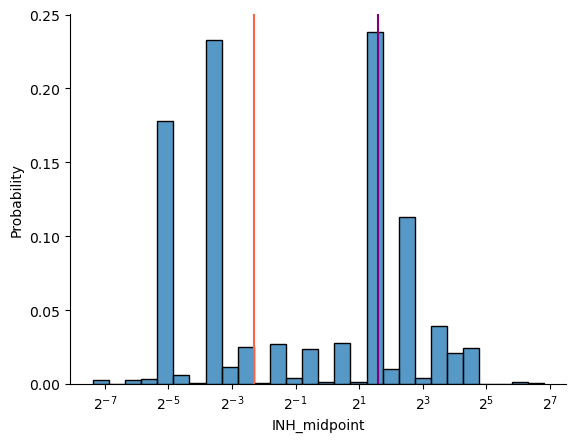

In [9]:
drug = 'INH'
cc = 0.2
out_dir = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}"

df = pd.read_csv(f"{out_dir}/data_for_model.csv")
print(df.shape)
# scaled_data = np.log2(df_combined[f'{drug}_midpoint_NORM']).values

sns.histplot(data=df.query("category=='train_set'"),
             x=f'{drug}_midpoint',
             # hue='category',
             multiple='dodge',
             stat='probability',
             common_norm=False,
             log_scale=2
            )

plt.axvline(cc, color='tomato')
plt.axvline(df.query("category=='train_set'")[f'{drug}_midpoint'].mean(), color='purple')

sns.despine()
plt.show()

<Axes: xlabel='INH_midpoint', ylabel='Proportion'>

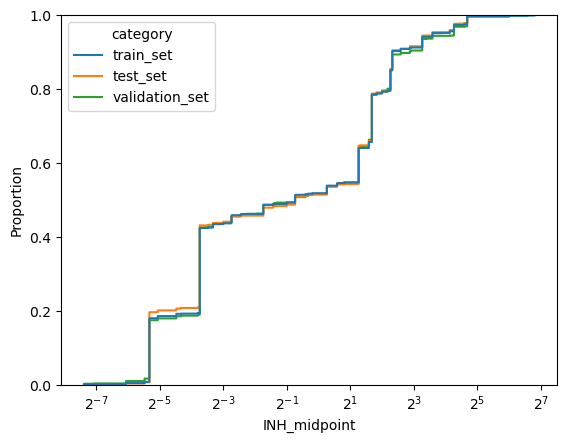

In [10]:
sns.ecdfplot(data=df,
             hue='category',
             x=f'{drug}_midpoint',
             log_scale=2
            )

In [119]:
df[f'{drug}_midpoint'].mean(), np.exp2(np.log2(df[f'{drug}_midpoint']).mean())

(5.644478007329061, 0.5441402330226177)

In [88]:
df_combined.query("Coll2014.str.contains('BOVAFRI')")

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016


In [87]:
df_combined

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016
0,SAMEA104362043,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.014747,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem
1,SAMEA104362045,7H10,0.00,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010044,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM
2,SAMEA104362046,7H10,0.06,0.090,0.12,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006304,4.9,4.2.1.1.1.1.1.1.i2,canetti,NaN,4.10/PGG3
3,SAMEA104362047,7H10,0.00,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.023915,4.3.2,4.2.1.2.1.1.i1,"lam,westafrican1",NaN,4.3/LAM
4,SAMEA104362048,7H10,0.00,0.030,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.025014,4.1.2,4.1.i1.1.1.2,haarlem,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11960,C476,7H10,4.00,6.000,8.00,MYCOTB,CASS,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013597,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN
11962,C478,7H10,0.00,0.015,0.03,MYCOTB,CASS,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016860,4.1.1.3,4.1.i1.2.1,xtype,NaN,4
11963,C480,7H10,4.00,6.000,8.00,MYCOTB,CASS,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013108,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN
11965,C485,7H10,0.00,0.015,0.03,MYCOTB,CASS,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010353,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM


In [92]:
F2_dict = {}
missing_lst = []

for i, sample_id in enumerate(df_combined.ROLLINGDB_ID.values):

    dir_names = ['genomic_data', 'cryptic_output', 'MIC_ML']

    for dir_name in dir_names:
        if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/{dir_name}/{sample_id}/pilon/{sample_id}_variants_combinedCodons.vcf"):
            missing_lst.append(sample_id)
        else:
            with open(f"/n/data1/hms/dbmi/farhat/rollingDB/{dir_name}/{sample_id}/lineage_calling/{sample_id}_F2_Coll2014.txt", "r") as file:
                F2 = file.readlines()
                assert len(F2) == 1
                df_combined.loc[i, 'F2'] = float(F2[0])

In [93]:
df_combined.loc[pd.isnull(df_combined['F2'])]

,ROLLINGDB_ID,BDQ_PHENOTYPE_QUALITY,BDQ_lower_bound,BDQ_upper_bound,BDQ_midpoint,MEDIA_NORM,BDQ_lower_bound_NORM,BDQ_midpoint_NORM,BDQ_upper_bound_NORM,MEDIA,DB_OF_ORIGIN,F2
86,SAMEA104362142,HIGH,0.030,0.06,0.0450,7H11,0.030,0.0450,0.060,UKMYC,CRyPTIC,NaN
87,SAMEA104362143,HIGH,0.015,0.03,0.0225,7H11,0.015,0.0225,0.030,UKMYC,CRyPTIC,NaN
88,SAMEA104362144,HIGH,0.015,0.03,0.0225,7H11,0.015,0.0225,0.030,UKMYC,CRyPTIC,NaN
89,SAMEA104362145,HIGH,0.030,0.06,0.0450,7H11,0.030,0.0450,0.060,UKMYC,CRyPTIC,NaN
93,SAMEA104362149,HIGH,0.015,0.03,0.0225,7H11,0.015,0.0225,0.030,UKMYC,CRyPTIC,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10451,TRL0119723,NaN,NaN,NaN,NaN,7H11,0.521,0.7815,1.042,BMD,NICD,NaN
10452,TRL0120480,NaN,NaN,NaN,NaN,7H11,0.250,0.3855,0.521,BMD,NICD,NaN
10453,TRL0120481,NaN,NaN,NaN,NaN,7H11,0.521,0.7815,1.042,BMD,NICD,NaN
10454,YA00004560,NaN,NaN,NaN,NaN,7H11,0.250,0.3855,0.521,BMD,NICD,NaN


In [95]:
df_combined.loc[~pd.isnull(df_combined['F2'])].F2.max()

0.4713236332815369

In [97]:
df_combined.DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
CRyPTIC       9889
NICD           396
Kreiswirth      96
Gandhi          75
Name: count, dtype: int64

In [3]:
df_1 = pd.read_csv("../MIC_data/MIC_ML.csv")
df_1['DB_OF_ORIGIN'] = "MICML"

df_2 = pd.read_csv("../MIC_data/rollingDB_MIC_raw.csv").rename(columns={'BioSample': 'ROLLINGDB_ID'})
df_2['DB_OF_ORIGIN'] = 'rollingDB'

# df_3 = pd.read_csv("../MIC_data/CRyPTIC_normalized.csv")
df_3 = cryptic_metadata.copy().rename(columns={'BioSample': 'ROLLINGDB_ID'})
df_3['DB_OF_ORIGIN'] = 'CRyPTIC'
df_3['MEDIA'] = 'UKMYC'

df_all = pd.concat([df_1, df_2, df_3]).reset_index(drop=True)
df_all['Run'] = df_all['Run'].fillna(df_all['ROLLINGDB_ID'])
df_all['Combined_Runs'] = df_all['Combined_Runs'].fillna(df_all['ROLLINGDB_ID'])

In [4]:
df_all.shape, df_all.ROLLINGDB_ID.nunique()

((17187, 62), 16441)

In [5]:
missing_fastq = []

for i, row in df_all.iterrows():

    sample_id = row['ROLLINGDB_ID']
    run = row['Run']

    if not os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/{run}"):
        missing_fastq.append(sample_id)

print(len(missing_fastq), len(np.unique(missing_fastq)))

# drop samples for which there are no FASTQs
df_all = df_all.query("ROLLINGDB_ID not in @missing_fastq").reset_index(drop=True)
len(df_all)

579 579


16608

In [6]:
df_all.loc[pd.isnull(df_all['ROLLINGDB_ID'])]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,ReleaseDate,Combined_Runs,Num_Runs,Model,Kraken2_Unclassified_Proportion,Median_Depth,PropGenome15x,PropGenome20x,PropGenome25x,PropGenome30x


In [82]:
fNames_to_annot = []

for i, row in df_all.iterrows():

    sample_id = row['ROLLINGDB_ID']
    run = row['Run']

    dir_names = ['cryptic_output', 'genomic_data']
    found_sample = False

    for dir_name in dir_names:

        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/{dir_name}/{sample_id}"):
            found_sample = True
            full_dir_name = f"/n/data1/hms/dbmi/farhat/rollingDB/{dir_name}/{sample_id}"
            break

    # there should be a directory for every sample
    assert found_sample

    if os.path.isfile(f"{full_dir_name}/pilon/{sample_id}_full.vcf.gz"):
        assert os.path.isfile(f"{full_dir_name}/pilon/{sample_id}_variants_combinedCodons.eff.vcf")
        assert os.path.isfile(f"{full_dir_name}/lineage_calling/{sample_id}_F2_Coll2014.txt")
        
        df_all.loc[i, 'VCF'] = f"{full_dir_name}/pilon/{sample_id}_variants_combinedCodons.eff.vcf"

        with open(f"{full_dir_name}/lineage_calling/{sample_id}_F2_Coll2014.txt", "r") as file:
            F2 = file.readlines()
            assert len(F2) == 1
            df_all.loc[i, 'F2'] = float(F2[0])

        # at least 1 BAM file must have passed minumum coverage requirements if there is a VCF file
        with open(f"{full_dir_name}/bam/pass_run_IDs.txt", 'r') as file:
            pass_runs = file.readlines()
            df_all.loc[i, 'Num_BAMs_passed_cov'] = len(pass_runs)
    
    # kraken file must exist, either in the sample_ID or an associated sequencing run
    if os.path.isfile(f"{full_dir_name}/kraken/kraken_report"):
        kraken_fName = f"{full_dir_name}/kraken/kraken_report"
    else:
        kraken_fName = f"{full_dir_name}/{run}/kraken/kraken_report"
        assert os.path.isfile(kraken_fName)

    # already computed for CRyPTIC samples
    if pd.isnull(row['Kraken2_Unclassified_Proportion']):
        kraken_report = pd.read_csv(kraken_fName, sep='\t', header=None)

        if 'unclassified' in kraken_report[5].values:
            kraken_unclassified = kraken_report.loc[kraken_report[5]=='unclassified'][0].values[0]
        else:
            kraken_unclassified = 0
            
        df_all.loc[i, 'Kraken2_Unclassified_Proportion'] = kraken_unclassified / 100

    else:
        missing_dirs.append(sample_id)

    if i % 5000 == 0:
        print(i)

fNames_to_annot = np.unique(fNames_to_annot)
assert sum(pd.isnull(df_all['Kraken2_Unclassified_Proportion'])) == 0

0
5000
10000
15000


In [85]:
len(high_qual_samples), df_all.ROLLINGDB_ID.nunique()

(0, 15862)

In [65]:
len(fNames_to_annot), len(np.unique(fNames_to_annot))

(0, 0)

In [92]:
df_all.loc[pd.isnull(df_all['F2'])].VCF.unique()

array(['nan'], dtype=object)

In [93]:
df_all.query("VCF=='nan'")['F2'].unique()

array([nan])

In [94]:
15862-1858

14004

In [96]:
df_all.query("VCF!='nan'").DB_OF_ORIGIN.unique()

array(['MICML', 'rollingDB', 'CRyPTIC'], dtype=object)

In [99]:
df_all.query("VCF!='nan'").drop_duplicates('ROLLINGDB_ID', keep=False).DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
CRyPTIC      10750
rollingDB     1517
MICML         1460
Name: count, dtype: int64

In [18]:
pd.Series(fNames_to_annot).to_csv("../../data_cleaning/fNames_to_annot.txt", sep='\t', header=None, index=False)

In [ ]:
snpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -no-downstream -no-upstream -lof -fileList fNames_to_annot.txt

In [23]:
annot_names = []

for name in fNames_to_annot:
    assert os.path.isfile(name.replace('.vcf', '.eff.vcf'))
    annot_names.append(name.replace('.vcf', '.eff.vcf'))

In [21]:
df_all.query("Run.str.contains('Peru')")

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,ReleaseDate,Combined_Runs,Num_Runs,Model,Kraken2_Unclassified_Proportion,Median_Depth,PropGenome15x,PropGenome20x,PropGenome25x,PropGenome30x
2946,NaN,SAMN05825228,Peru,rollingDB,NJH,7H10,>50,>5,>2.5,NaN,...,NaN,Peru4700,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2947,NaN,SAMN05830624,Peru,rollingDB,NJH,7H10,>50,>5,>2.5,NaN,...,NaN,Peru4701,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2948,NaN,SAMN05830709,Peru,rollingDB,NJH,7H10,>50,2-4,1.5-2.5,NaN,...,NaN,Peru4702,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949,NaN,SAMN05830710,Peru,rollingDB,NJH,7H10,>50,>5,>2.5,NaN,...,NaN,Peru4703,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2950,NaN,SAMN05830711,Peru,rollingDB,NJH,7H10,>50,>5,1.5-2.5,NaN,...,NaN,Peru4704,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3939,NaN,SAMN06094116,Peru,rollingDB,NJH,7H10,>50,>5,>2.5,NaN,...,NaN,Peru5449,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3940,NaN,SAMN06094117,Peru,rollingDB,NJH,7H10,>50,>5,>2.5,NaN,...,NaN,Peru5450,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3941,NaN,SAMN06094120,Peru,rollingDB,NJH,7H10,5-8,0.1-0.2,1-1.5,NaN,...,NaN,Peru5453,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3942,NaN,SAMN06094121,Peru,rollingDB,NJH,7H10,>50,>5,0.25-0.5,NaN,...,NaN,Peru5454,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
trust_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/231218.TRUST.Illumina.Batch3.Output"
trust_df = pd.DataFrame(columns = ['VCF', 'F2'])

for i, isolate in enumerate(os.listdir(trust_dir)):

    fName = f"{trust_dir}/{isolate}/pilon/{isolate}_variants.vcf"
    
    if os.path.isfile(fName):

        with open(f"{trust_dir}/{isolate}/F2_metric/{isolate}_F2.txt") as file:
            F2 = file.readlines()
            assert len(F2) == 1
    
    trust_df.loc[i, ['VCF', 'F2']] = [fName, float(F2[0])]

In [182]:
len(os.listdir(trust_dir))

152

In [181]:
trust_df

,VCF,F2
0,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.009669
1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.016293
2,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.011881
3,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.011524
4,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.021959
...,...,...
147,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.496774
148,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.496774
149,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.496774
150,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/23121...,0.496774


In [158]:
df_keep = pd.read_csv("full_data/samples_pheno_geno.csv")

In [162]:
df_keep.query("F2 < 0.05")

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2
0,20542,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.027387
1,21849,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012577
2,23768,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015828
4,26243,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013581
5,30571,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.021311
...,...,...,...,...
14120,SAMEA7544392,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009321
14121,SAMEA8719049,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.007628
14122,SAMEA8718896,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016184
14123,SAMEA8718780,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010611


In [156]:
df_keep.loc[pd.isnull(df_keep['F2'])]

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2


In [153]:
df_keep.shape

(14125, 3)

In [157]:
df_keep.to_csv("full_data/samples_pheno_geno.csv", index=False)

In [129]:
df_all.loc[pd.isnull(df_all['MEDIA'])]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,Model,Kraken2_Unclassified_Proportion,Median_Depth,PropGenome15x,PropGenome20x,PropGenome25x,PropGenome30x,Num_BAMs_passed_cov,VCF,F2


In [109]:
df_all.query("VCF!='nan'")[['VCF']].drop_duplicates().to_csv("fNames_for_extraction.txt", sep='\t', header=None, index=False)

In [110]:
annot_names = pd.read_csv("fNames_for_extraction.txt", sep='\t', header=None)
len(annot_names), len(np.unique(annot_names))

(14125, 14125)

In [ ]:
sbatch extract_group1_variants.sh fNames_for_extraction.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv